# 05 – Train / Calibration / Test Split 

**Purpose.** Dataset is split on **vehicle level** (not the row level), so that all rows of one vehicle land in the same set. This is mandatory for a valid conformal anomaly detector: row-level splitting would let the model see consecutive frames of the same trajectory in different splits, leaking the rolling-window state, the cluster-median, and the 'normal' distribution.

The three splits:
- **Train (60%)** — defines what 'normal' looks like (the empirical distribution of nonconformity scores will be computed against this).
- **Calibration (20%)** – produces the calibration quantile that defines the conformal threshold for a given significance level ε.
- **Test (20%)** — held out for final evaluation. Never touched until the detector is locked.

## Design choices

1. **Stratified by `is_anomalous_trajectory`** — preserves the per-set rate of rule-flagged trajectories. With ~25% trajectories flagged, a non-stratified split on 273 vehicles could give wildly imbalanced anomaly rates between splits; stratification fixes this. On full data this matters less but is still good practice.
2. **Stratified by `cluster`** — preserves the entry/exit corridor distribution, so the test set isn't dominated by corridors that the train set rarely saw. Combined with the anomaly stratification, this is the closest to representative splits without making the split deterministic.
3. **Fixed random seed** — reproducibility.
4. **Persisted as a column** — the split is written back to the parquet as `split ∈ {train, cal, test}`, so downstream notebooks just read it instead of re-deriving.

## Known caveats for the conformal pipeline downstream

- `deviation_m` was computed in notebook 02 against cluster medians built from **all vehicles, including test**. Strictly, this is a minor leakage: the path-deviation feature of test-set rows used the test-set trajectories in defining the 'normal path'. For a fully leak-free pipeline, the cluster medians should be re-fit on training data only. It's flagged here so it can be addressed in notebook 06 (the conformal detector) as an optional refit step. For sub-question 1's discriminative-power analysis it does not matter; for sub-question 2's detector validity it is a defensible methodological point to document and (optionally) fix.
- The rolling-window features (`*_1s`, `*_2s`) are computed only within a single trajectory, so they don't leak across vehicles. No fix needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

## 1. Parameters and load

In [2]:
IN_PATH = Path('features_labelled.parquet') 
OUT_PATH = Path('features_split.parquet')

TRAIN_FRAC = 0.60
CAL_FRAC   = 0.20
TEST_FRAC  = 0.20  # must sum to 1.0
RANDOM_SEED = 42

assert abs(TRAIN_FRAC + CAL_FRAC + TEST_FRAC - 1.0) < 1e-9

df = pd.read_parquet(IN_PATH)
if 'cluster' in df.columns:
    df['cluster'] = df['cluster'].apply(lambda c: tuple(c) if hasattr(c, '__iter__') else c)

print(f'Rows: {len(df):,}')
print(f'Vehicles: {df["ID"].nunique():,}')
print(f'Anomalous trajectories: {df.groupby("ID")["is_anomalous_trajectory"].first().sum()}')

Rows: 1,372,369
Vehicles: 46,578
Anomalous trajectories: 12704


## 2. Build per-vehicle stratification key

In [3]:
# One row per vehicle, holding stratification info.
per_veh = df.groupby('ID').agg(
    is_anomalous=('is_anomalous_trajectory', 'first'),
    cluster=('cluster', 'first'),
).reset_index()

# Combined stratification key: (anomaly_flag, cluster). Small clusters get folded into 'other'
# to avoid sklearn's 'least populated class has < 2 members' error.
cluster_counts = per_veh['cluster'].value_counts()
MIN_CLUSTER_FOR_STRAT = 10  # clusters smaller than this don't get their own stratum
rare_clusters = set(cluster_counts[cluster_counts < MIN_CLUSTER_FOR_STRAT].index)
per_veh['cluster_strat'] = per_veh['cluster'].apply(lambda c: 'other' if c in rare_clusters else str(c))
per_veh['strat_key'] = per_veh['is_anomalous'].astype(str) + '|' + per_veh['cluster_strat']

# Check strat key counts; warn on any stratum with < 3 vehicles (can't split into 3 sets).
strat_counts = per_veh['strat_key'].value_counts()
print('Stratification key counts:')
print(strat_counts.head(20).to_string())
small = strat_counts[strat_counts < 3]
if len(small) > 0:
    print(f'\nWARNING: {len(small)} strata have < 3 vehicles. These will be folded into a fallback stratum.')
    # Fold tiny strata into one bucket per anomaly status.
    fallback = per_veh['strat_key'].isin(small.index)
    per_veh.loc[fallback, 'strat_key'] = per_veh.loc[fallback, 'is_anomalous'].astype(str) + '|fallback'
    print(f'After fallback fold:')
    print(per_veh["strat_key"].value_counts().to_string())

Stratification key counts:
strat_key
False|(5, 2)    8590
False|(2, 7)    6016
True|(2, 7)     4207
False|(2, 2)    3919
False|(4, 2)    2770
False|(2, 1)    2298
True|(2, 6)     2248
False|(3, 2)    1983
True|(2, 2)     1914
True|(2, 1)     1798
False|(2, 6)    1761
False|(5, 7)    1438
False|(7, 6)    1188
True|(5, 2)      859
False|(7, 7)     643
False|(6, 7)     484
False|(5, 3)     433
False|(5, 6)     398
False|(4, 3)     346
True|(4, 2)      333

After fallback fold:
strat_key
False|(5, 2)     8590
False|(2, 7)     6016
True|(2, 7)      4207
False|(2, 2)     3919
False|(4, 2)     2770
False|(2, 1)     2298
True|(2, 6)      2248
False|(3, 2)     1983
True|(2, 2)      1914
True|(2, 1)      1798
False|(2, 6)     1761
False|(5, 7)     1438
False|(7, 6)     1188
True|(5, 2)       859
False|(7, 7)      643
False|(6, 7)      484
False|(5, 3)      433
False|(5, 6)      398
False|(4, 3)      346
True|(4, 2)       333
False|(4, 7)      308
False|(6, 6)      239
True|(5, 6)       239
True|

## 3. Perform the split

First peel off the test set (20%), then split the remaining 80% into train (60% of total = 75% of remainder) and calibration (20% of total = 25% of remainder).

In [4]:
# Step 1: split test off from the rest.
non_test, test = train_test_split(
    per_veh,
    test_size=TEST_FRAC,
    stratify=per_veh['strat_key'],
    random_state=RANDOM_SEED,
)

# Step 2: split non-test into train and cal.
# We want train = TRAIN_FRAC of original = TRAIN_FRAC / (1 - TEST_FRAC) of non-test.
train_frac_of_nontest = TRAIN_FRAC / (1 - TEST_FRAC)
train, cal = train_test_split(
    non_test,
    train_size=train_frac_of_nontest,
    stratify=non_test['strat_key'],
    random_state=RANDOM_SEED,
)

split_map = {}
for vid in train['ID']: split_map[vid] = 'train'
for vid in cal['ID']:   split_map[vid] = 'cal'
for vid in test['ID']:  split_map[vid] = 'test'

df['split'] = df['ID'].map(split_map)

print(f'Vehicles per split:')
print(f'  train: {len(train):4d}  ({len(train)/len(per_veh)*100:.1f}%)')
print(f'  cal:   {len(cal):4d}  ({len(cal)/len(per_veh)*100:.1f}%)')
print(f'  test:  {len(test):4d}  ({len(test)/len(per_veh)*100:.1f}%)')
print(f'\nRows per split:')
print(df['split'].value_counts().to_string())

Vehicles per split:
  train: 27946  (60.0%)
  cal:   9316  (20.0%)
  test:  9316  (20.0%)

Rows per split:
split
train    823743
test     275566
cal      273060


## 4. Validate the split

Three checks: (a) anomaly rates roughly match across splits, (b) cluster distribution roughly matches, (c) temporal coverage is similar.

In [5]:
print('=== Check (a) — anomaly rate per split (per vehicle) ===')
anom_per_split = df.groupby('split').apply(
    lambda g: g.groupby('ID')['is_anomalous_trajectory'].first().mean(),
    include_groups=False
)
print(anom_per_split.round(3).to_string())

print('\n=== Check (b) — top cluster proportions per split ===')
per_veh_with_split = per_veh.assign(split=per_veh['ID'].map(split_map))
top_clusters = per_veh['cluster_strat'].value_counts().head(5).index
for c in top_clusters:
    by_split = per_veh_with_split[per_veh_with_split['cluster_strat'] == c]['split'].value_counts(normalize=True)
    print(f'  cluster {c}: ' + '  '.join([f'{s}={by_split.get(s, 0):.2f}' for s in ['train', 'cal', 'test']]))

print('\n=== Check (c) — temporal coverage per split ===')
df_time = df.copy()
df_time['Time'] = pd.to_datetime(df_time['Time'])
by_split_time = df_time.groupby('split')['Time'].agg(['min', 'max', 'count'])
print(by_split_time)

=== Check (a) — anomaly rate per split (per vehicle) ===
split
cal      0.273
test     0.272
train    0.273

=== Check (b) — top cluster proportions per split ===
  cluster (2, 7): train=0.60  cal=0.20  test=0.20
  cluster (5, 2): train=0.60  cal=0.20  test=0.20
  cluster (2, 2): train=0.60  cal=0.20  test=0.20
  cluster (2, 1): train=0.60  cal=0.20  test=0.20
  cluster (2, 6): train=0.60  cal=0.20  test=0.20

=== Check (c) — temporal coverage per split ===
                                   min                              max  \
split                                                                     
cal   2018-05-22 16:31:04.610000+02:00 2018-05-25 09:14:47.654000+02:00   
test  2018-05-22 16:31:08.249000+02:00 2018-05-25 09:14:47.524000+02:00   
train 2018-05-22 16:31:19.760000+02:00 2018-05-25 09:14:47.575000+02:00   

        count  
split          
cal    273060  
test   275566  
train  823743  


## 5. Visualise the split

A quick spatial map to make sure no split is geographically biased.

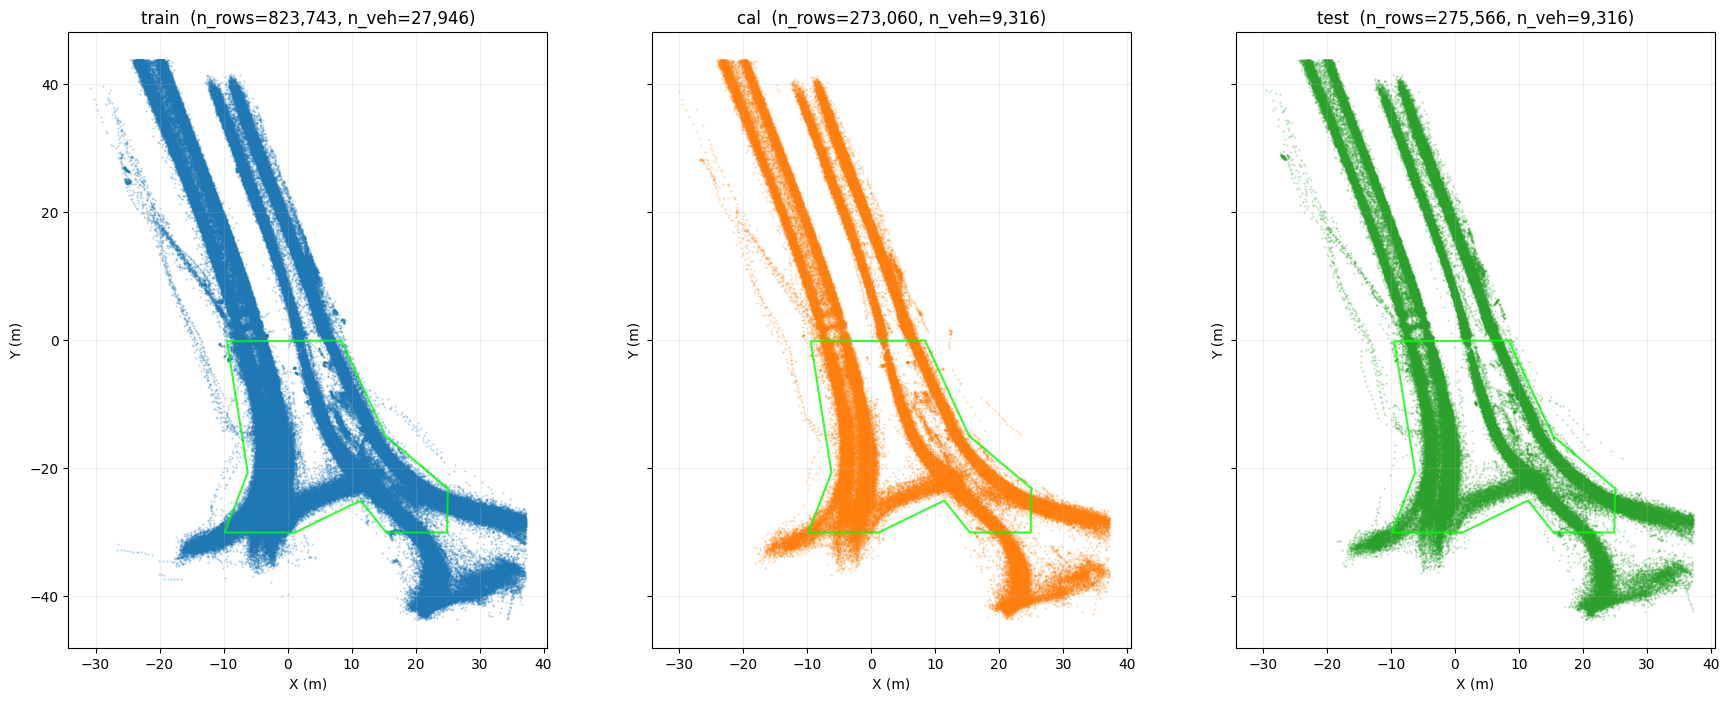

In [6]:
from conflict_zone_polygon import CONFLICT_ZONE_POLYGON
pxy = np.array(CONFLICT_ZONE_POLYGON)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)
colours = {'train': 'tab:blue', 'cal': 'tab:orange', 'test': 'tab:green'}
for ax, split in zip(axes, ['train', 'cal', 'test']):
    sub = df[df['split'] == split]
    ax.scatter(sub['X'], sub['Y'], s=0.3, c=colours[split], alpha=0.3)
    ax.plot(np.append(pxy[:, 0], pxy[0, 0]), np.append(pxy[:, 1], pxy[0, 1]),
            '-', color='lime', linewidth=1.5, alpha=0.8)
    ax.set_title(f'{split}  (n_rows={len(sub):,}, n_veh={sub["ID"].nunique():,})')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('split_map.png', dpi=110)
plt.show()

## 6. Save the split

The split column is written back to a new parquet so notebook 06 (conformal detector) can just read it.

In [7]:
df.to_parquet(OUT_PATH, index=False)
print(f'Saved {len(df):,} rows × {len(df.columns)} columns to {OUT_PATH}')
print(f'  split column added: train={len(train):,}, cal={len(cal):,}, test={len(test):,} vehicles')

Saved 1,372,369 rows × 50 columns to features_split.parquet
  split column added: train=27,946, cal=9,316, test=9,316 vehicles


## 7. Summary for thesis writing

For the thesis!

In [8]:
anom_rates = anom_per_split.round(3).to_dict()
summary = (
    f'The dataset contains {df["ID"].nunique():,} unique vehicles ({len(df):,} trajectory points). '
    f'These were split at the vehicle level into a training set ({len(train)} vehicles, {anom_rates["train"]*100:.1f}% rule-flagged), '
    f'a calibration set ({len(cal)} vehicles, {anom_rates["cal"]*100:.1f}% rule-flagged), '
    f'and a held-out test set ({len(test)} vehicles, {anom_rates["test"]*100:.1f}% rule-flagged), '
    f'stratified by anomaly status and entry/exit corridor with a fixed random seed of {RANDOM_SEED}.'
)
print(summary)

The dataset contains 46,578 unique vehicles (1,372,369 trajectory points). These were split at the vehicle level into a training set (27946 vehicles, 27.3% rule-flagged), a calibration set (9316 vehicles, 27.3% rule-flagged), and a held-out test set (9316 vehicles, 27.2% rule-flagged), stratified by anomaly status and entry/exit corridor with a fixed random seed of 42.
